# RL Toy Problem: Decoder Environment with Stable Baselines3

This notebook trains and evaluates different agents on the DecoderEnv:
1. Random agent (baseline)
2. Greedy agent (always picks minimum MI cluster)
3. DQN agent
4. PPO agent

In [2]:
# Import necessary libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
import pandas as pd

# Add the gymnasium_env to the path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

2025-12-16 01:19:42.931940: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-16 01:19:42.999115: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-16 01:19:44.606052: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical 

In [3]:
# Register and create the environment
import gymnasium_env

env = gym.make("gymnasium_env/Decoder-v0", render_mode=None, num_clusters=6, max_iterations=10)
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Test the environment
obs, info = env.reset()
print(f"\nInitial observation: {obs}")
print(f"Initial info: {info}")

Observation space: Box(0.0, 1.0, (6,), float32)
Action space: Discrete(6)

Initial observation: [0.07985226 0.058812   0.11841688 0.12581141 0.16815421 0.16394688]
Initial info: {'iteration': 0, 'average_mi': 0.11916560782077702, 'min_mi': 0.05881200162574696, 'max_mi': 0.16815420641564155}


/root/.pyenv/versions/myenv/lib/python3.12/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment gymnasium_env/Decoder-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


## 1. Random Agent (Baseline)

In [4]:
def evaluate_random_agent(env, n_episodes=100):
    """Evaluate random agent performance"""
    episode_rewards = []
    episode_lengths = []
    final_avg_mis = []
    
    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        episode_reward = 0
        steps = 0
        
        while not done:
            action = env.action_space.sample()  # Random action
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            steps += 1
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(steps)
        final_avg_mis.append(info['average_mi'])
    
    return {
        'mean_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
        'mean_length': np.mean(episode_lengths),
        'mean_final_mi': np.mean(final_avg_mis),
        'rewards': episode_rewards
    }

random_results = evaluate_random_agent(env, n_episodes=100)
print("Random Agent Results:")
print(f"  Mean Reward: {random_results['mean_reward']:.4f} ± {random_results['std_reward']:.4f}")
print(f"  Mean Episode Length: {random_results['mean_length']:.2f}")
print(f"  Mean Final Average MI: {random_results['mean_final_mi']:.4f}")

Random Agent Results:
  Mean Reward: 0.3796 ± 0.0279
  Mean Episode Length: 10.00
  Mean Final Average MI: 0.4830


## 2. Greedy Agent (Minimum MI)

In [5]:
def evaluate_greedy_agent(env, n_episodes=100):
    """Evaluate greedy agent that always picks cluster with minimum MI"""
    episode_rewards = []
    episode_lengths = []
    final_avg_mis = []
    
    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        episode_reward = 0
        steps = 0
        
        while not done:
            action = np.argmin(obs)  # Choose cluster with minimum MI
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            steps += 1
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(steps)
        final_avg_mis.append(info['average_mi'])
    
    return {
        'mean_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
        'mean_length': np.mean(episode_lengths),
        'mean_final_mi': np.mean(final_avg_mis),
        'rewards': episode_rewards
    }

greedy_results = evaluate_greedy_agent(env, n_episodes=100)
print("Greedy Agent Results:")
print(f"  Mean Reward: {greedy_results['mean_reward']:.4f} ± {greedy_results['std_reward']:.4f}")
print(f"  Mean Episode Length: {greedy_results['mean_length']:.2f}")
print(f"  Mean Final Average MI: {greedy_results['mean_final_mi']:.4f}")

Greedy Agent Results:
  Mean Reward: 0.4583 ± 0.0000
  Mean Episode Length: 10.00
  Mean Final Average MI: 0.5586


## 3. DQN Agent

In [10]:
# Create directories for saving models and logs
os.makedirs("models/dqn", exist_ok=True)
os.makedirs("logs/dqn", exist_ok=True)

# Create training environment with Monitor wrapper
train_env = gym.make("gymnasium_env/Decoder-v0", num_clusters=6, max_iterations=10)
train_env = Monitor(train_env, "logs/dqn/train")

# Create evaluation environment
eval_env = gym.make("gymnasium_env/Decoder-v0", num_clusters=6, max_iterations=10)
eval_env = Monitor(eval_env, "logs/dqn/eval")

# Create DQN model
dqn_model = DQN(
    "MlpPolicy",
    train_env,
    learning_rate=1e-3,
    buffer_size=10000,
    learning_starts=1000,
    batch_size=64,
    tau=1.0,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1000,
    exploration_fraction=0.1,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    verbose=1,
    tensorboard_log="logs/dqn"
)

print("DQN model created successfully")

Using cuda device
Wrapping the env in a DummyVecEnv.
DQN model created successfully


In [11]:
# Train DQN model
print("Training DQN agent...")
dqn_model.learn(total_timesteps=10000, log_interval=10, progress_bar=True)

# Save the model
dqn_model.save("models/dqn/final_model")
print("DQN model saved to models/dqn/final_model")

Training DQN agent...
Logging to logs/dqn/DQN_6


Output()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.368    |
|    exploration_rate | 0.905    |
| time/               |          |
|    episodes         | 10       |
|    fps              | 3223     |
|    time_elapsed     | 0        |
|    total_timesteps  | 100      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.368    |
|    exploration_rate | 0.81     |
| time/               |          |
|    episodes         | 20       |
|    fps              | 4370     |
|    time_elapsed     | 0        |
|    total_timesteps  | 200      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.372    |
|    exploration_rate | 0.715    |
| time/               |          |
|    episodes       

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.373    |
|    exploration_rate | 0.43     |
| time/               |          |
|    episodes         | 60       |
|    fps              | 4888     |
|    time_elapsed     | 0        |
|    total_timesteps  | 600      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.373    |
|    exploration_rate | 0.335    |
| time/               |          |
|    episodes         | 70       |
|    fps              | 5173     |
|    time_elapsed     | 0        |
|    total_timesteps  | 700      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.375    |
|    exploration_rate | 0.24     |
| time/               |          |
|    episodes       

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.361    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 110      |
|    fps              | 1769     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1100     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.0029   |
|    n_updates        | 24       |
----------------------------------


...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.355    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 970      |
|    fps              | 352      |
|    time_elapsed     | 27       |
|    total_timesteps  | 9700     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.00016  |
|    n_updates        | 2174     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.353    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 980      |
|    fps              | 351      |
|    time_elapsed     | 27       |
|    total_timesteps  | 9800     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 8.31e-05 |
|    n_updates        | 2199     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.353    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 990      |
|    fps              | 350      |
|    time_elapsed     | 28       |
|    total_timesteps  | 9900     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 7.86e-05 |
|    n_updates        | 2224     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 0.353    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1000     |
|    fps              | 349      |
|    time_elapsed     | 28       |
|    total_timesteps  | 10000    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 7.21e-05 |
|    n_updates        | 2249     |
----------------------------------


DQN model saved to models/dqn/final_model


In [17]:
# Evaluate DQN model
dqn_mean_reward, dqn_std_reward = evaluate_policy(dqn_model, eval_env, n_eval_episodes=100, deterministic=True)

print(f"\nDQN Agent Results:")
print(f"  Mean Reward: {dqn_mean_reward:.4f} ± {dqn_std_reward:.4f}")

# Store DQN results
dqn_results = {
    'mean_reward': dqn_mean_reward,
    'std_reward': dqn_std_reward
}


DQN Agent Results:
  Mean Reward: 0.3409 ± 0.0432


## 4. PPO Agent

In [6]:
# Create directories for PPO
os.makedirs("models/ppo", exist_ok=True)
os.makedirs("logs/ppo", exist_ok=True)

# Create training environment for PPO
ppo_train_env = gym.make("gymnasium_env/Decoder-v0", num_clusters=6, max_iterations=10)
ppo_train_env = Monitor(ppo_train_env, "logs/ppo/train")

# Create evaluation environment for PPO
ppo_eval_env = gym.make("gymnasium_env/Decoder-v0", num_clusters=6, max_iterations=10)
ppo_eval_env = Monitor(ppo_eval_env, "logs/ppo/eval")

# Create PPO model
ppo_model = PPO(
    "MlpPolicy",
    ppo_train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,
    verbose=1,
    tensorboard_log="logs/ppo"
)

print("PPO model created successfully")

Using cuda device
Wrapping the env in a DummyVecEnv.
PPO model created successfully


/root/.pyenv/versions/myenv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [7]:
# Train PPO model
print("Training PPO agent...")
ppo_model.learn(total_timesteps=10000, log_interval=10, progress_bar=True)

# Save the model
ppo_model.save("models/ppo/final_model")
print("PPO model saved to models/ppo/final_model")

Training PPO agent...
Logging to logs/ppo/PPO_4


Output()

PPO model saved to models/ppo/final_model


In [8]:
# Evaluate PPO model
ppo_mean_reward, ppo_std_reward = evaluate_policy(ppo_model, ppo_eval_env, n_eval_episodes=100, deterministic=True)

print(f"\nPPO Agent Results:")
print(f"  Mean Reward: {ppo_mean_reward:.4f} ± {ppo_std_reward:.4f}")

# Store PPO results
ppo_results = {
    'mean_reward': ppo_mean_reward,
    'std_reward': ppo_std_reward
}


PPO Agent Results:
  Mean Reward: 0.4512 ± 0.0038


## 5. Results Comparison and Visualization

In [18]:
# Compile results
results_summary = pd.DataFrame({
    'Agent': ['Random', 'Greedy (Min MI)', 'DQN', 'PPO'],
    'Mean Reward': [
        random_results['mean_reward'],
        greedy_results['mean_reward'],
        dqn_results['mean_reward'],
        ppo_results['mean_reward']
    ],
    'Std Reward': [
        random_results['std_reward'],
        greedy_results['std_reward'],
        dqn_results['std_reward'],
        ppo_results['std_reward']
    ]
})

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(results_summary.to_string(index=False))
print("="*60)

# Save results to CSV
os.makedirs("results", exist_ok=True)
results_summary.to_csv("results/agent_comparison.csv", index=False)
print("\nResults saved to results/agent_comparison.csv")


FINAL RESULTS SUMMARY
          Agent  Mean Reward   Std Reward
         Random     0.379590 2.792761e-02
Greedy (Min MI)     0.458333 8.063460e-17
            DQN     0.340883 4.316468e-02
            PPO     0.451201 3.808470e-03

Results saved to results/agent_comparison.csv


/tmp/ipykernel_29836/331116188.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(reward_data, labels=['Random', 'Greedy'], patch_artist=True)


Comparison plots saved to results/agent_comparison.png


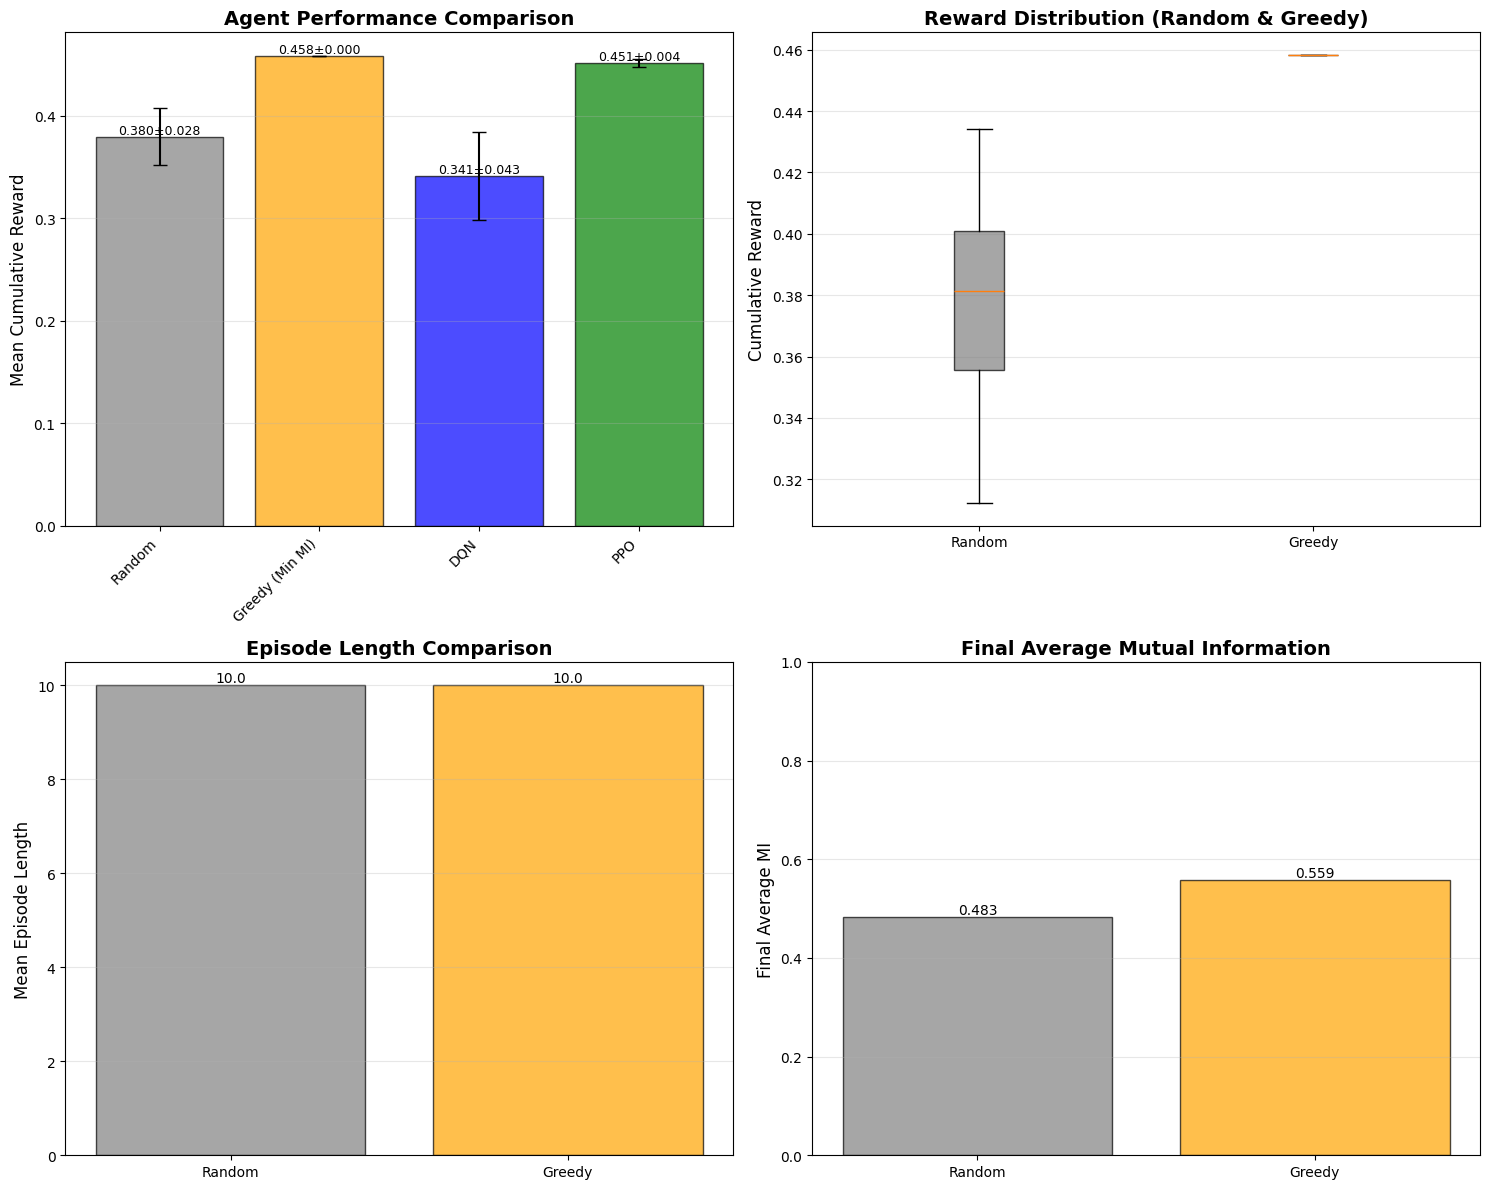

In [19]:
# Plot 1: Mean Reward Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Bar plot of mean rewards
ax = axes[0, 0]
agents = results_summary['Agent']
means = results_summary['Mean Reward']
stds = results_summary['Std Reward']
colors = ['gray', 'orange', 'blue', 'green']

bars = ax.bar(agents, means, yerr=stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Mean Cumulative Reward', fontsize=12)
ax.set_title('Agent Performance Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.3f}±{std:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: Reward Distribution (Box plot)
ax = axes[0, 1]
reward_data = [
    random_results['rewards'],
    greedy_results['rewards'],
]

bp = ax.boxplot(reward_data, labels=['Random', 'Greedy'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:2]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Cumulative Reward', fontsize=12)
ax.set_title('Reward Distribution (Random & Greedy)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 3: Episode Length Comparison
ax = axes[1, 0]
episode_lengths = [random_results['mean_length'], greedy_results['mean_length']]
agent_names = ['Random', 'Greedy']
bars = ax.bar(agent_names, episode_lengths, color=colors[:2], alpha=0.7, edgecolor='black')
ax.set_ylabel('Mean Episode Length', fontsize=12)
ax.set_title('Episode Length Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, length in zip(bars, episode_lengths):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{length:.1f}',
            ha='center', va='bottom', fontsize=10)

# Plot 4: Final Average MI
ax = axes[1, 1]
final_mis = [random_results['mean_final_mi'], greedy_results['mean_final_mi']]
bars = ax.bar(agent_names, final_mis, color=colors[:2], alpha=0.7, edgecolor='black')
ax.set_ylabel('Final Average MI', fontsize=12)
ax.set_title('Final Average Mutual Information', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

for bar, mi in zip(bars, final_mis):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mi:.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/agent_comparison.png', dpi=300, bbox_inches='tight')
print("Comparison plots saved to results/agent_comparison.png")
plt.show()

Training curves saved to results/training_curves.png


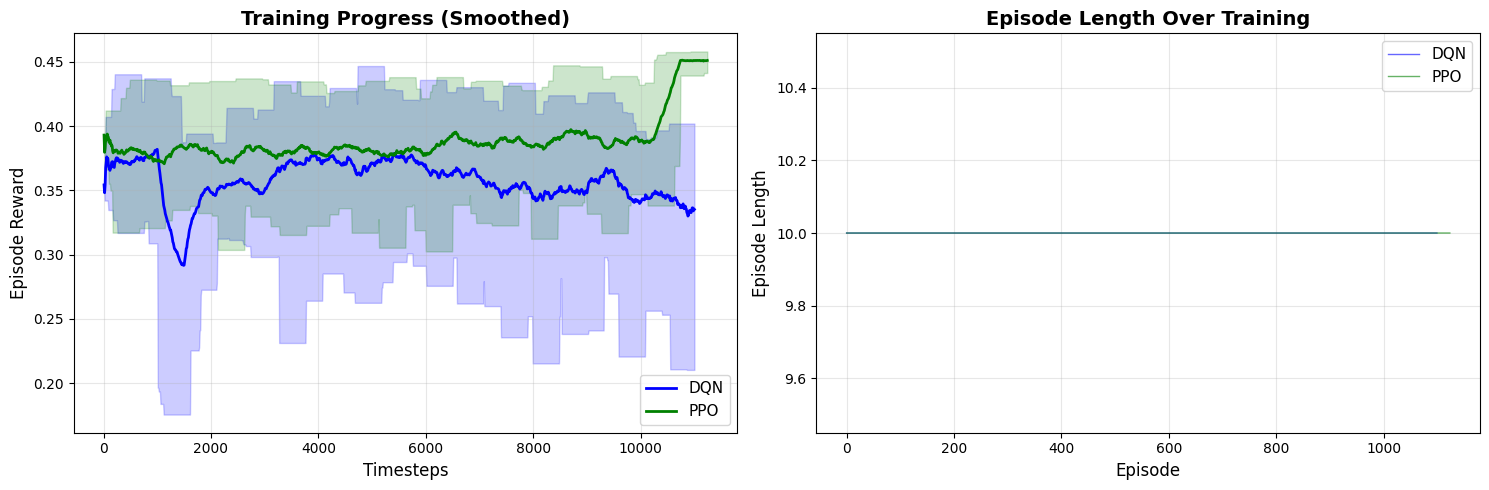

In [23]:
# Load and plot training curves from Monitor logs
def plot_training_curves():
    """Plot learning curves from training logs"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Load training data
    try:
        from stable_baselines3.common.results_plotter import load_results, ts2xy
        
        # DQN learning curve
        dqn_log_dir = "logs/dqn"
        ppo_log_dir = "logs/ppo"
        
        has_data = False
        
        if os.path.exists(dqn_log_dir):
            try:
                dqn_results = load_results(dqn_log_dir)
                if len(dqn_results) > 0:
                    x_dqn, y_dqn = ts2xy(dqn_results, 'timesteps')
                    
                    # Moving average for smoothing
                    window_size = min(50, len(y_dqn) // 2 + 1)
                    y_dqn_smooth = pd.Series(y_dqn).rolling(window=window_size, min_periods=1).mean()
                    
                    axes[0].plot(x_dqn, y_dqn_smooth, label='DQN', color='blue', linewidth=2)
                    axes[0].fill_between(x_dqn, 
                                        pd.Series(y_dqn).rolling(window=window_size, min_periods=1).min(),
                                        pd.Series(y_dqn).rolling(window=window_size, min_periods=1).max(),
                                        alpha=0.2, color='blue')
                    
                    # Episode length over time
                    axes[1].plot(dqn_results['l'].values, label='DQN', color='blue', alpha=0.6, linewidth=1)
                    has_data = True
            except Exception as e:
                print(f"Could not load DQN results: {e}")
        
        # PPO learning curve
        if os.path.exists(ppo_log_dir):
            try:
                ppo_results = load_results(ppo_log_dir)
                if len(ppo_results) > 0:
                    x_ppo, y_ppo = ts2xy(ppo_results, 'timesteps')
                    
                    window_size = min(50, len(y_ppo) // 2 + 1)
                    y_ppo_smooth = pd.Series(y_ppo).rolling(window=window_size, min_periods=1).mean()
                    
                    axes[0].plot(x_ppo, y_ppo_smooth, label='PPO', color='green', linewidth=2)
                    axes[0].fill_between(x_ppo,
                                        pd.Series(y_ppo).rolling(window=window_size, min_periods=1).min(),
                                        pd.Series(y_ppo).rolling(window=window_size, min_periods=1).max(),
                                        alpha=0.2, color='green')
                    
                    # Episode length over time
                    axes[1].plot(ppo_results['l'].values, label='PPO', color='green', alpha=0.6, linewidth=1)
                    has_data = True
            except Exception as e:
                print(f"Could not load PPO results: {e}")
        
        if has_data:
            axes[0].set_xlabel('Timesteps', fontsize=12)
            axes[0].set_ylabel('Episode Reward', fontsize=12)
            axes[0].set_title('Training Progress (Smoothed)', fontsize=14, fontweight='bold')
            axes[0].legend(fontsize=11)
            axes[0].grid(alpha=0.3)
            
            axes[1].set_xlabel('Episode', fontsize=12)
            axes[1].set_ylabel('Episode Length', fontsize=12)
            axes[1].set_title('Episode Length Over Training', fontsize=14, fontweight='bold')
            axes[1].legend(fontsize=11)
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.savefig('results/training_curves.png', dpi=300, bbox_inches='tight')
            print("Training curves saved to results/training_curves.png")
            plt.show()
        else:
            print("No training data found. Make sure the Monitor wrapper is correctly configured.")
            print(f"Checked directories: {dqn_log_dir}, {ppo_log_dir}")
            plt.close(fig)
        
    except Exception as e:
        print(f"Error plotting training curves: {e}")
        import traceback
        traceback.print_exc()

plot_training_curves()

## 6. Visualize Agent Behavior on Single Episode

\nVisualizing Random Agent...


/root/.pyenv/versions/myenv/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.num_clusters to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_clusters` for environment variables or `env.get_wrapper_attr('num_clusters')` that will search the reminding wrappers.
  logger.warn(


Episode visualization saved to results/random_agent_episode.png


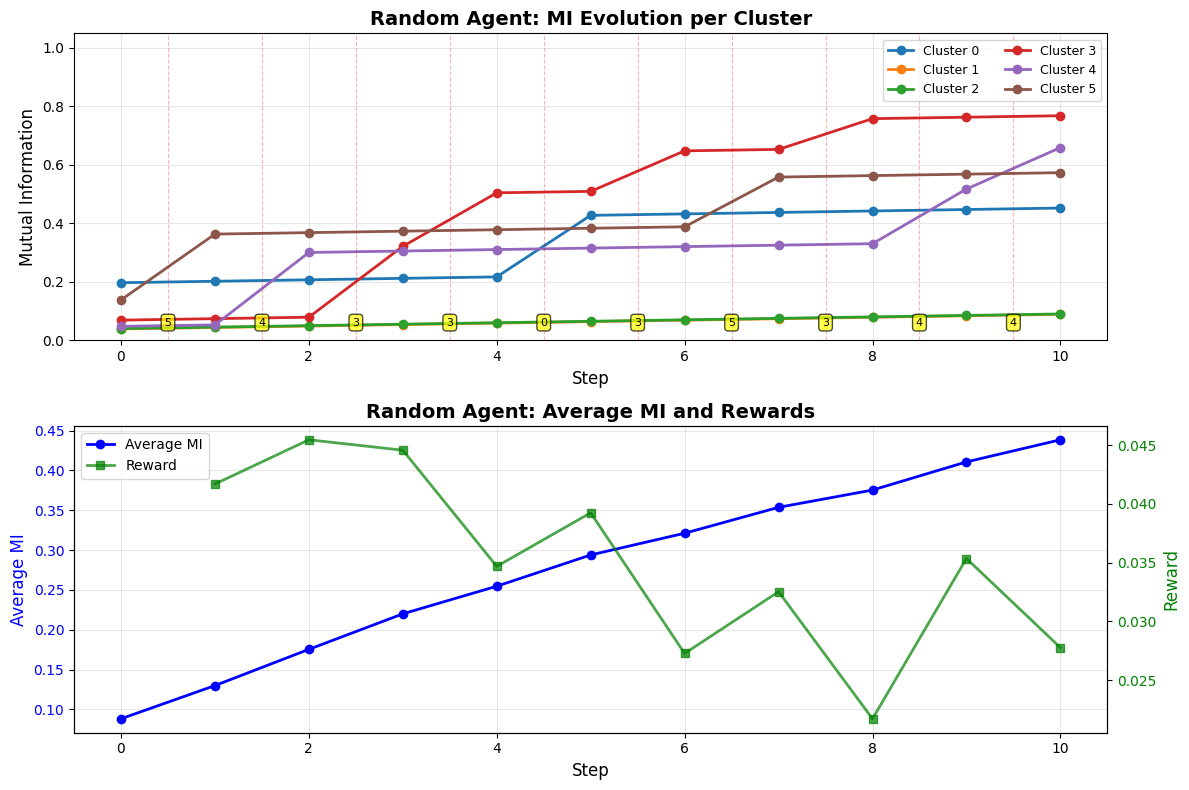

\nVisualizing Greedy Agent...
Episode visualization saved to results/greedy_agent_episode.png


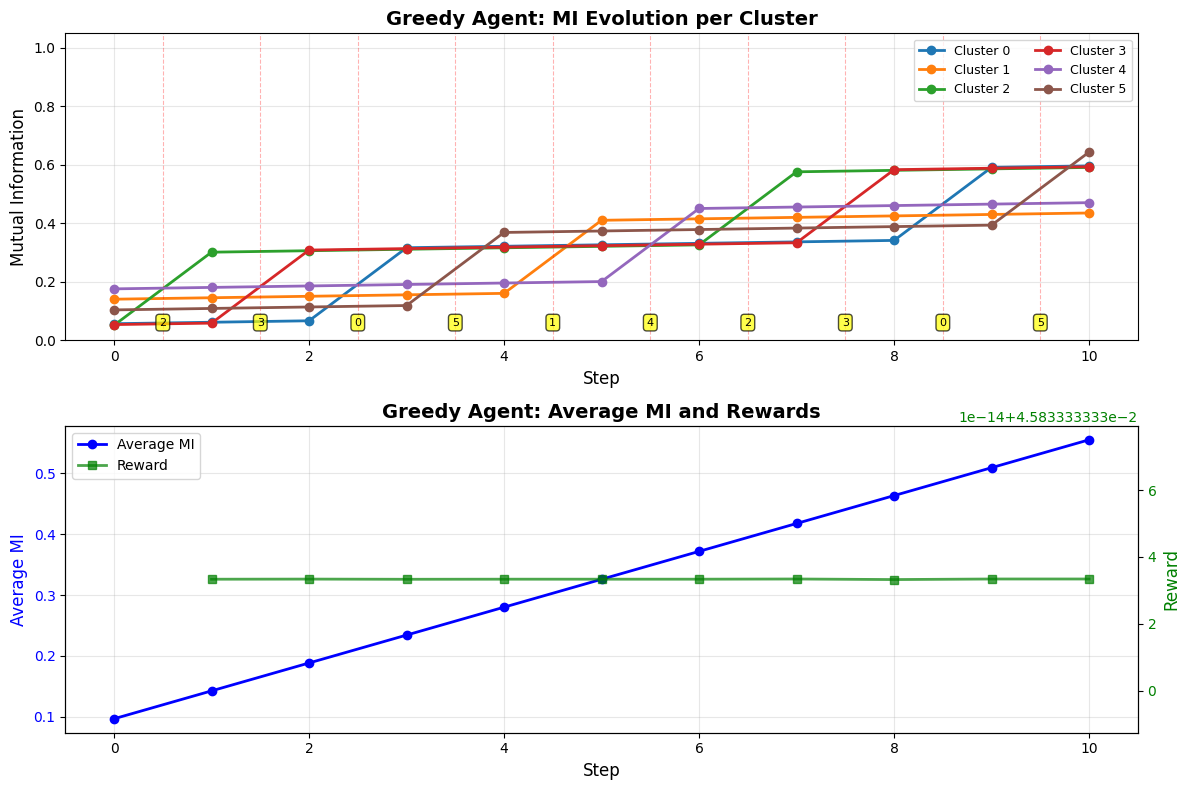

\nVisualizing DQN Agent...
Episode visualization saved to results/dqn_agent_episode.png


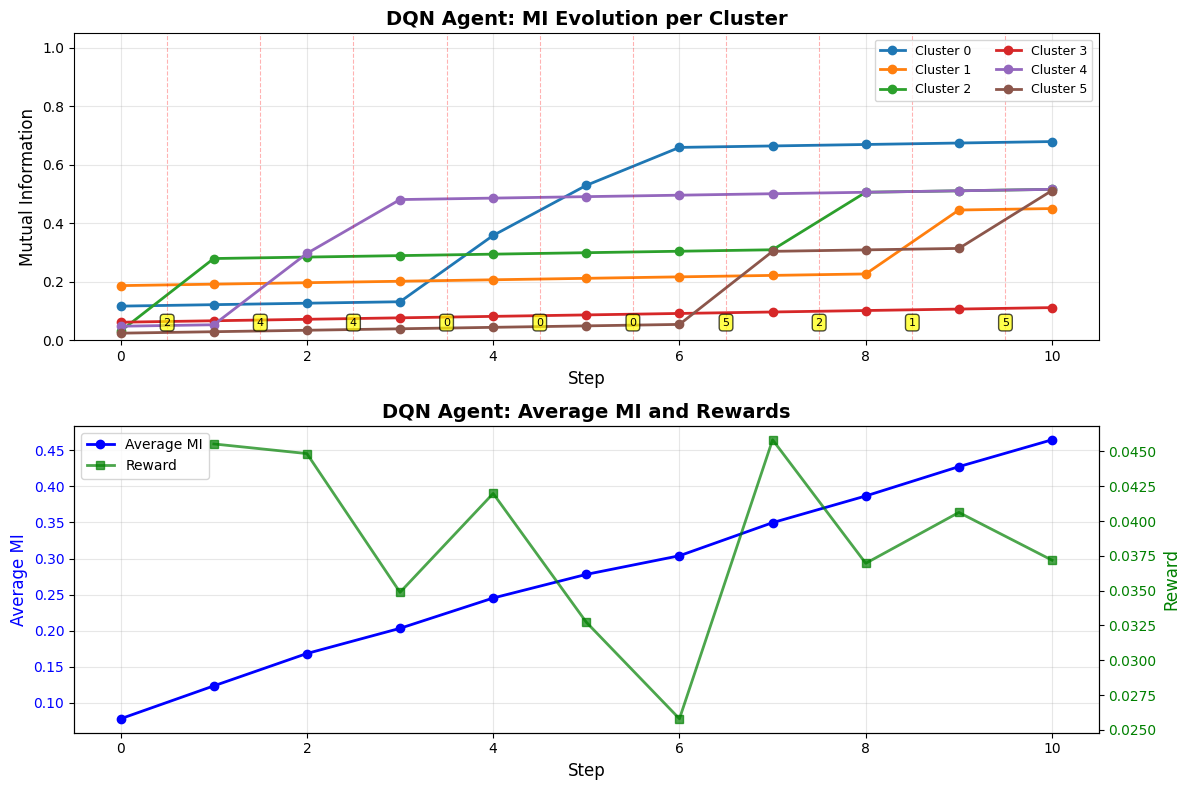

\nVisualizing PPO Agent...
Episode visualization saved to results/ppo_agent_episode.png


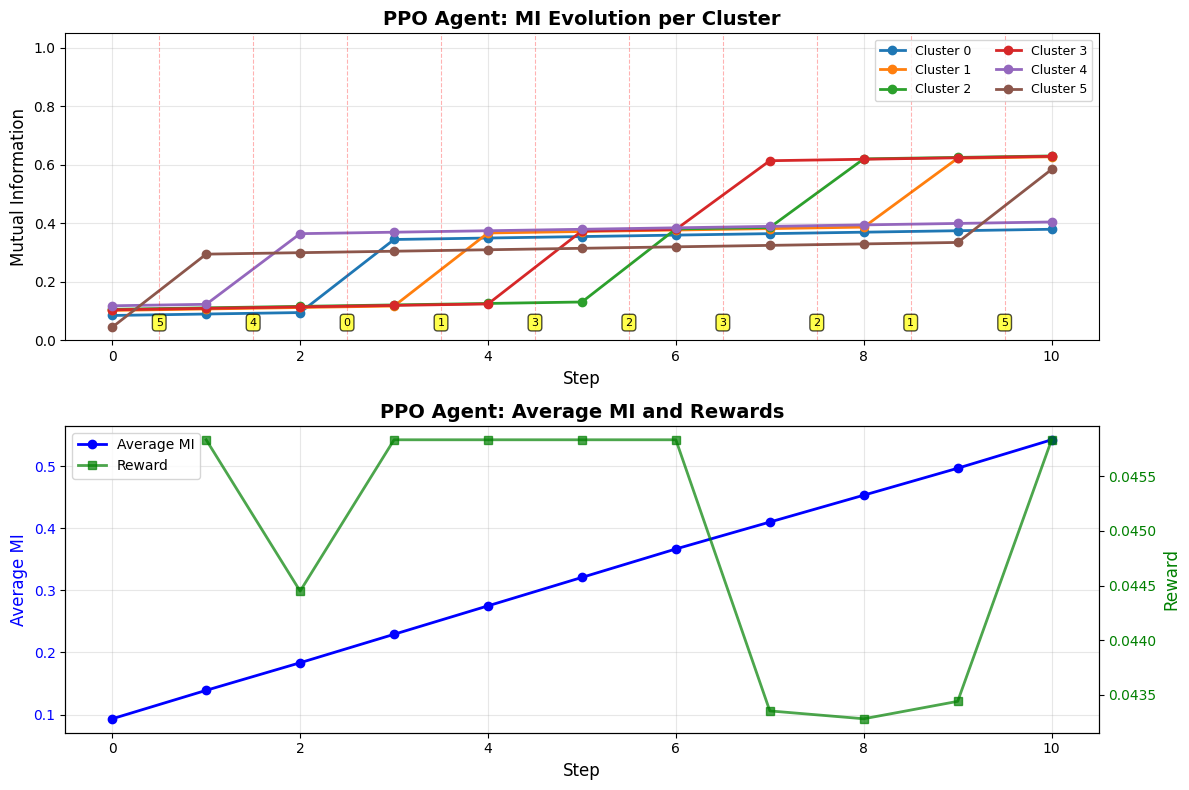

In [21]:
def visualize_episode(model, model_name, env):
    """Visualize a single episode showing MI evolution"""
    obs, info = env.reset()
    done = False
    
    mi_history = [obs.copy()]
    actions_taken = []
    rewards_history = []
    
    while not done:
        if model is None:  # Random agent
            action = env.action_space.sample()
        elif model == "greedy":  # Greedy agent
            action = np.argmin(obs)
        else:  # RL agent
            action, _ = model.predict(obs, deterministic=True)
        
        actions_taken.append(action)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        mi_history.append(obs.copy())
        rewards_history.append(reward)
    
    # Plot MI evolution
    mi_history = np.array(mi_history)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: MI evolution per cluster
    ax = axes[0]
    for cluster in range(env.num_clusters):
        ax.plot(mi_history[:, cluster], marker='o', label=f'Cluster {cluster}', linewidth=2)
    
    # Mark actions with vertical lines
    for step, action in enumerate(actions_taken):
        ax.axvline(x=step+0.5, color='red', linestyle='--', alpha=0.3, linewidth=0.8)
        ax.text(step+0.5, 0.05, str(action), ha='center', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax.set_xlabel('Step', fontsize=12)
    ax.set_ylabel('Mutual Information', fontsize=12)
    ax.set_title(f'{model_name}: MI Evolution per Cluster', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.05])
    
    # Plot 2: Average MI and rewards
    ax = axes[1]
    avg_mi = np.mean(mi_history, axis=1)
    
    ax2 = ax.twinx()
    line1 = ax.plot(avg_mi, 'b-o', label='Average MI', linewidth=2, markersize=6)
    line2 = ax2.plot(range(1, len(rewards_history)+1), rewards_history, 'g-s', 
                     label='Reward', linewidth=2, markersize=6, alpha=0.7)
    
    ax.set_xlabel('Step', fontsize=12)
    ax.set_ylabel('Average MI', color='b', fontsize=12)
    ax2.set_ylabel('Reward', color='g', fontsize=12)
    ax.set_title(f'{model_name}: Average MI and Rewards', fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='b')
    ax2.tick_params(axis='y', labelcolor='g')
    ax.grid(alpha=0.3)
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'results/{model_name.lower().replace(" ", "_")}_episode.png', dpi=300, bbox_inches='tight')
    print(f"Episode visualization saved to results/{model_name.lower().replace(' ', '_')}_episode.png")
    plt.show()
    
    return mi_history, actions_taken, rewards_history

# Create fresh environments for visualization
viz_env = gym.make("gymnasium_env/Decoder-v0", num_clusters=6, max_iterations=10)

print("\\nVisualizing Random Agent...")
viz_env.reset(seed=42)
random_mi, random_actions, random_rewards = visualize_episode(None, "Random Agent", viz_env)

print("\\nVisualizing Greedy Agent...")
viz_env.reset(seed=42)
greedy_mi, greedy_actions, greedy_rewards = visualize_episode("greedy", "Greedy Agent", viz_env)

print("\\nVisualizing DQN Agent...")
viz_env.reset(seed=42)
dqn_mi, dqn_actions, dqn_rewards = visualize_episode(dqn_model, "DQN Agent", viz_env)

print("\\nVisualizing PPO Agent...")
viz_env.reset(seed=42)
ppo_mi, ppo_actions, ppo_rewards = visualize_episode(ppo_model, "PPO Agent", viz_env)

## 7. Save All Models and Results Summary

In [22]:
# Save detailed results
detailed_results = {
    'random': {
        'mean_reward': random_results['mean_reward'],
        'std_reward': random_results['std_reward'],
        'mean_length': random_results['mean_length'],
        'mean_final_mi': random_results['mean_final_mi'],
        'all_rewards': random_results['rewards']
    },
    'greedy': {
        'mean_reward': greedy_results['mean_reward'],
        'std_reward': greedy_results['std_reward'],
        'mean_length': greedy_results['mean_length'],
        'mean_final_mi': greedy_results['mean_final_mi'],
        'all_rewards': greedy_results['rewards']
    },
    'dqn': {
        'mean_reward': dqn_results['mean_reward'],
        'std_reward': dqn_results['std_reward'],
    },
    'ppo': {
        'mean_reward': ppo_results['mean_reward'],
        'std_reward': ppo_results['std_reward'],
    }
}

# Save to pickle for complete data preservation
import pickle
with open('results/detailed_results.pkl', 'wb') as f:
    pickle.dump(detailed_results, f)

print("\\n" + "="*60)
print("ALL RESULTS SAVED")
print("="*60)
print("Models saved to:")
print("  - models/dqn/final_model.zip")
print("  - models/ppo/final_model.zip")
print("\\nResults saved to:")
print("  - results/agent_comparison.csv")
print("  - results/detailed_results.pkl")
print("\\nPlots saved to:")
print("  - results/agent_comparison.png")
print("  - results/training_curves.png")
print("  - results/random_agent_episode.png")
print("  - results/greedy_agent_episode.png")
print("  - results/dqn_agent_episode.png")
print("  - results/ppo_agent_episode.png")
print("\\nTensorBoard logs in:")
print("  - logs/dqn/")
print("  - logs/ppo/")
print("="*60)

\n============================================================
ALL RESULTS SAVED
Models saved to:
  - models/dqn/final_model.zip
  - models/ppo/final_model.zip
\nResults saved to:
  - results/agent_comparison.csv
  - results/detailed_results.pkl
\nPlots saved to:
  - results/agent_comparison.png
  - results/training_curves.png
  - results/random_agent_episode.png
  - results/greedy_agent_episode.png
  - results/dqn_agent_episode.png
  - results/ppo_agent_episode.png
\nTensorBoard logs in:
  - logs/dqn/
  - logs/ppo/
